# National housing price prediction

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBRegressor

## Load data and build features

In [3]:
df = pd.read_csv("national.csv")
df = df.drop_duplicates().reset_index(drop=True)

df["DATE"] = pd.to_datetime(df["DATE"])
df["House_Age"] = df["DATE"].dt.year - df["BUILT"]
df = df.drop(columns=["DATE", "BUILT"])

X = df.drop(columns="VALUE")
y = np.log1p(df["VALUE"])

print("rows:", len(df))
df.head()

rows: 35154


,DEGREE,METRO3,DIVISION,PER,ZADULT,ZINC2,ZSMHC,ELDER,DISH,COOK,...,GARAGE,BUSPER,CONDO,VALUE,HLTH,CELLAR,FPLWK,HHGRAD,TYPE,House_Age
0,Cold,"MSA, rural",Middle Atlantic,NaN,NaN,NaN,NaN,NaN,Yes,Yes,...,Yes,NaN,Condo,200000,NaN,Crawl space,Yes,NaN,"House, apartment, flat",5
1,Cold,"MSA, rural",Middle Atlantic,2.0,2.0,36200.0,662.0,2.0,Yes,Yes,...,Yes,0.0,Condo,222000,Very Good,Basement under all of the house,Yes,High school graduate,"House, apartment, flat",5
2,Cool,"Non-MSA, rural",South Atlantic & East South Central,NaN,NaN,NaN,NaN,NaN,No,Yes,...,No,NaN,Not Condo,120000,NaN,Crawl space,No,NaN,"House, apartment, flat",31
3,Cool,"Non-MSA, rural",South Atlantic & East South Central,1.0,1.0,44982.0,1000.0,0.0,Yes,Yes,...,Yes,0.0,Not Condo,125000,Very Good,Basement under all of the house,Yes,Some college but no degree,"House, apartment, flat",31
4,Cool,"Non-MSA, rural",South Atlantic & East South Central,NaN,NaN,NaN,NaN,NaN,Yes,Yes,...,No,NaN,Not Condo,110000,NaN,Basement under part of the house,Yes,NaN,"House, apartment, flat",4


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train = X_train.copy()
X_test = X_test.copy()

print("train rows:", len(X_train))
print("test rows:", len(X_test))

train rows: 28123
test rows: 7031


## Handle missing values

Numeric columns get filled with the training median and get a `_missing` flag column so the model can still tell which rows were originally empty. Categorical columns get filled with the training mode. Everything is fit on the train split only so no test information leaks in.

In [5]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

for col in numeric_cols:
    X_train[col + "_missing"] = X_train[col].isna().astype("int8") # extra features added so the model trains
    X_test[col + "_missing"] = X_test[col].isna().astype("int8") # on the columns with missing values , effieciency slightly increase

    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

for col in categorical_cols:
    mode = X_train[col].mode(dropna=True)[0]
    X_train[col] = X_train[col].fillna(mode)
    X_test[col] = X_test[col].fillna(mode)

In [6]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
encoder.fit(X_train[categorical_cols])

train_encoded = encoder.transform(X_train[categorical_cols])
test_encoded = encoder.transform(X_test[categorical_cols])

encoded_cols = encoder.get_feature_names_out(categorical_cols) # names the transformed cols
train_encoded = pd.DataFrame(train_encoded, columns=encoded_cols, index=X_train.index)
test_encoded = pd.DataFrame(test_encoded, columns=encoded_cols, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=categorical_cols), train_encoded], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_cols), test_encoded], axis=1)

print("features after encoding:", X_train.shape[1])

features after encoding: 78


SVR needs scaled inputs, the tree and linear models don't, so a scaled copy is kept separately.

In [7]:
scaler = RobustScaler() # better than standard scalar for outliers
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

actual_value = np.expm1(y_test)

## Model 1: Linear Regression

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred_log = lr_model.predict(X_test)
lr_pred = np.expm1(lr_pred_log)

lr_mae_log = mean_absolute_error(y_test, lr_pred_log)
lr_rmse_log = mean_squared_error(y_test, lr_pred_log) ** 0.5
lr_r2 = r2_score(y_test, lr_pred_log)
lr_mae_dollars = mean_absolute_error(actual_value, lr_pred)

print("Linear Regression")
print("MAE (log):", round(lr_mae_log, 4))
print("RMSE (log):", round(lr_rmse_log, 4))
print("R2 (log):", round(lr_r2, 4))
print("MAE ($):", round(lr_mae_dollars, 2))

Linear Regression
MAE (log): 0.4595
RMSE (log): 0.6242
R2 (log): 0.4796
MAE ($): 109946.49


## Model 2: SVR

In [9]:
svr_sample_size = 8000 # if used on all train , it will alllotttt of time
rng = np.random.RandomState(42)
svr_idx = rng.choice(len(X_train_scaled), size=svr_sample_size, replace=False)

# NOTE: kept on the same 8,000-row subsample

svr_param_grid = {
    "C": [1, 10, 100],
    "epsilon": [0.01, 0.05, 0.1],
    "gamma": ["scale", "auto"],
}

svr_grid = GridSearchCV(
    SVR(kernel="rbf"), #RBF (Radial Basis Function) kernel allows SVR to model
    svr_param_grid, #non-linear relationships, which are common in house-price prediction.
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
svr_grid.fit(X_train_scaled[svr_idx], y_train.iloc[svr_idx])

print("SVR best params:", svr_grid.best_params_)
print("SVR best CV RMSE (log):", round(-svr_grid.best_score_, 4))

svr_model = svr_grid.best_estimator_

svr_pred_log = svr_model.predict(X_test_scaled)
svr_pred = np.expm1(svr_pred_log)

svr_mae_log = mean_absolute_error(y_test, svr_pred_log)
svr_rmse_log = mean_squared_error(y_test, svr_pred_log) ** 0.5
svr_r2 = r2_score(y_test, svr_pred_log)
svr_mae_dollars = mean_absolute_error(actual_value, svr_pred)

print("SVR")
print("MAE (log):", round(svr_mae_log, 4))
print("RMSE (log):", round(svr_rmse_log, 4))
print("R2 (log):", round(svr_r2, 4))
print("MAE ($):", round(svr_mae_dollars, 2))


SVR best params: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto'}
SVR best CV RMSE (log): 0.6182
SVR
MAE (log): 0.4437
RMSE (log): 0.6079
R2 (log): 0.5063
MAE ($): 105786.06


## Model 3: XGBoost

In [10]:
xgb_param_grid = {
    "max_depth": [4, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [300, 500],
}

xgb_grid = GridSearchCV(
    XGBRegressor(
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        n_jobs=1,  
        random_state=42,
    ),
    xgb_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
xgb_grid.fit(X_train, y_train)

print("XGBoost best params:", xgb_grid.best_params_)
print("XGBoost best CV RMSE (log):", round(-xgb_grid.best_score_, 4))

xgb_model = xgb_grid.best_estimator_

xgb_pred_log = xgb_model.predict(X_test)
xgb_pred = np.expm1(xgb_pred_log)

xgb_mae_log = mean_absolute_error(y_test, xgb_pred_log)
xgb_rmse_log = mean_squared_error(y_test, xgb_pred_log) ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred_log)
xgb_mae_dollars = mean_absolute_error(actual_value, xgb_pred)

print("XGBoost")
print("MAE (log):", round(xgb_mae_log, 4))
print("RMSE (log):", round(xgb_rmse_log, 4))
print("R2 (log):", round(xgb_r2, 4))
print("MAE ($):", round(xgb_mae_dollars, 2))


XGBoost best params: {'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 500}
XGBoost best CV RMSE (log): 0.5871
XGBoost
MAE (log): 0.4266
RMSE (log): 0.5872
R2 (log): 0.5393
MAE ($): 101801.49


## Compare the three models

In [11]:
results_df = pd.DataFrame([
    {"Model": "Linear Regression", "MAE (log)": lr_mae_log, "RMSE (log)": lr_rmse_log, "R2 (log)": lr_r2, "MAE ($)": lr_mae_dollars},
    {"Model": "SVR", "MAE (log)": svr_mae_log, "RMSE (log)": svr_rmse_log, "R2 (log)": svr_r2, "MAE ($)": svr_mae_dollars},
    {"Model": "XGBoost", "MAE (log)": xgb_mae_log, "RMSE (log)": xgb_rmse_log, "R2 (log)": xgb_r2, "MAE ($)": xgb_mae_dollars},
])
results_df = results_df.sort_values("RMSE (log)").reset_index(drop=True)
results_df.round(4)

,Model,MAE (log),RMSE (log),R2 (log),MAE ($)
0,XGBoost,0.4266,0.5872,0.5393,101801.4871
1,SVR,0.4437,0.6079,0.5063,105786.0608
2,Linear Regression,0.4595,0.6242,0.4796,109946.4897


In [12]:
predictions_by_model = {
    "Linear Regression": lr_pred,
    "SVR": svr_pred,
    "XGBoost": xgb_pred,
}

best_model_name = results_df.loc[0, "Model"]
predicted_value = predictions_by_model[best_model_name]
print("best model by log RMSE:", best_model_name)

best model by log RMSE: XGBoost


## Actual vs. predicted

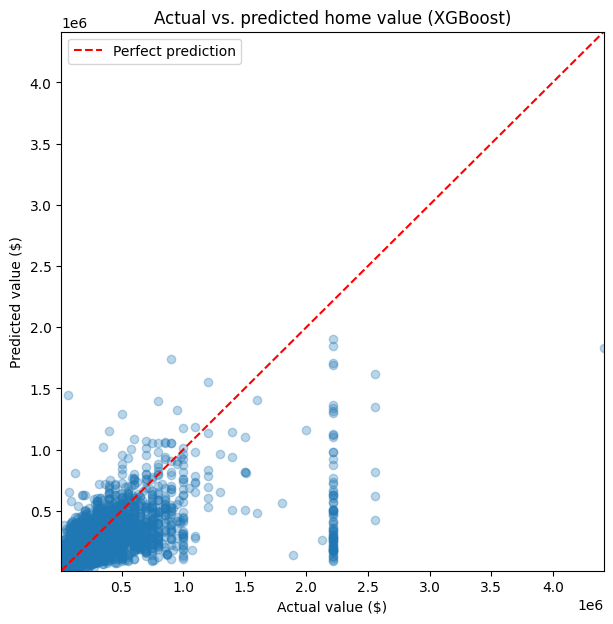

In [13]:
plt.figure(figsize=(7, 7))
plt.scatter(actual_value, predicted_value, alpha=0.30)

limits = [min(actual_value.min(), predicted_value.min()), max(actual_value.max(), predicted_value.max())]
plt.plot(limits, limits, color="red", linestyle="--", label="Perfect prediction")
plt.xlim(limits)
plt.ylim(limits)
plt.xlabel("Actual value ($)")
plt.ylabel("Predicted value ($)")
plt.title(f"Actual vs. predicted home value ({best_model_name})")
plt.legend()
plt.show()

## Save models for deployment

Saves the 3 fitted models plus the encoder, scaler, and the training-set medians/modes so the Streamlit app can preprocess new input exactly the way the training data was preprocessed.

In [14]:
import pickle
from sklearn.model_selection import train_test_split as _train_test_split

# recover the raw (pre-fill, pre-encoding) training split to capture clean
# medians/modes -- X_train/X_test above have already been filled and encoded
_X_train_raw, _, _, _ = _train_test_split(X, y, test_size=0.20, random_state=42)

medians = {col: _X_train_raw[col].median() for col in numeric_cols}
modes = {col: _X_train_raw[col].mode(dropna=True)[0] for col in categorical_cols}

artifacts = {
    "models": {"Linear Regression": lr_model, "SVR": svr_model, "XGBoost": xgb_model},
    "encoder": encoder,
    "scaler": scaler,
    "numeric_cols": numeric_cols,
    "categorical_cols": categorical_cols,
    "medians": medians,
    "modes": modes,
    "feature_order": X_train.columns.tolist(),
    "results_df": results_df,
    "raw_columns": X.columns.tolist(),
    "categorical_options": {c: sorted(X[c].dropna().unique().tolist()) for c in categorical_cols},
}

with open("housing_models.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("Saved housing_models.pkl -- run: streamlit run app.py")


Saved housing_models.pkl -- run: streamlit run app.py
